<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports

In [61]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# Globals


In [62]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
OUTPUT_DIR = 'results/rgb_baseline'

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Setup repository



In [63]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
/content/REPO
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 52.53 KiB | 2.92 MiB/s, done.
From https://github.com/Alessandro-json/AI_PostProcessing_Detection
   641ab1b..8b294bc  main       -> origin/main
Updating 641ab1b..8b294bc
Fast-forward
 notebook.ipynb | 604 +++++++++++++++++++++++++--------------------------------
 1 file changed, 266 insertions(+), 338 deletions(-)


# Install dependencies

In [64]:
# Install project dependencies.
!pip install -r requirements.txt


In [65]:
!pip install -q gdown

# Utils

In [66]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')


# Data


In [67]:
train_df = show_csv_summary(TRAIN_CSV)


File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [68]:
val_df = show_csv_summary(VAL_CSV)


File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [69]:
test_df = show_csv_summary(TEST_CSV)


File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [70]:
!gdown --id "$DATASET_FILE_ID" -O "$DATASET_ZIP_PATH"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI
From (redirected): https://drive.google.com/uc?id=1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI&confirm=t&uuid=6d2de807-f781-4287-8076-2cf2543c69ef
To: /content/RRDataset_subset.zip
100% 1.27G/1.27G [00:09<00:00, 137MB/s]


In [71]:
!rm -rf /content/data/raw/RRDataset_subset
!mkdir -p /content/data/raw
!unzip -n -q "$DATASET_ZIP_PATH" -d /content/data/raw

In [72]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)


Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# Train

This cell launches training for the RGB multi-task baseline.


In [73]:
!python src/train.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint_name {CHECKPOINT_NAME} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --lambda_fake {LAMBDA_FAKE} \
  --lambda_transform {LAMBDA_TRANSFORM}


Using device: cuda

Epoch 1/10
Training:  11% 7/66 [00:04<00:35,  1.67it/s]
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1524, in _next_data
    idx, data = self._get_data()
                ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1473, in _get_data
    success, data = self._try_get_data()
                    ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1310, in _try_get_data
    data = self._data_queue.get(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/queue.py", line 180, in get
    self.not_empty.wait(remaining)
  File "/usr/lib/python3.12/threading.py", line 359, in wait
    gotit 

# Evaluation

This cell evaluates the best checkpoint and saves:

- `predictions.csv`;
- `metrics.json`;
- `confusion_fake.png`;
- `confusion_transform.png`.


In [74]:
!python src/evaluate.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint {CHECKPOINT_PATH} \
  --output_dir {OUTPUT_DIR} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}


Using device: cuda
Traceback (most recent call last):
  File "/content/REPO/src/evaluate.py", line 437, in <module>
    main()
  File "/content/REPO/src/evaluate.py", line 416, in main
    predictions_df = evaluate_model(
                     ^^^^^^^^^^^^^^^
  File "/content/REPO/src/evaluate.py", line 77, in evaluate_model
    for batch in dataloader:
                 ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1524, in _next_data
    idx, data = self._get_data()
                ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1483, in _get_data
    success, data = self._try_get_data()
                    ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1310, in _t

# Results

In [75]:
metrics_path = Path(OUTPUT_DIR) / 'metrics.json'

if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    print(json.dumps(metrics, indent=4))
else:
    print(f'Metrics file not found: {metrics_path}')


{
    "fake_accuracy": 0.9111111111111111,
    "fake_f1_macro": 0.9110671936758893,
    "transform_accuracy": 0.7977777777777778,
    "transform_f1_macro": 0.7972683152445939,
    "fake_accuracy_by_transform": {
        "original": 0.92,
        "transfer": 0.9,
        "redigital": 0.9133333333333333
    }
}


In [76]:
predictions_path = Path(OUTPUT_DIR) / "predictions.csv"

if predictions_path.exists():
    predictions_df = pd.read_csv(predictions_path)
else:
    print(f"Predictions file not found: {predictions_path}")

In [77]:
print("True fake labels:")
print(predictions_df["true_fake"].value_counts())

print("\nPredicted fake labels:")
print(predictions_df["pred_fake"].value_counts())

print("\nTrue transform labels:")
print(predictions_df["true_transform"].value_counts())

print("\nPredicted transform labels:")
print(predictions_df["pred_transform"].value_counts())

True fake labels:
true_fake
0    225
1    225
Name: count, dtype: int64

Predicted fake labels:
pred_fake
1    235
0    215
Name: count, dtype: int64

True transform labels:
true_transform
0    150
1    150
2    150
Name: count, dtype: int64

Predicted transform labels:
pred_transform
1    162
2    154
0    134
Name: count, dtype: int64


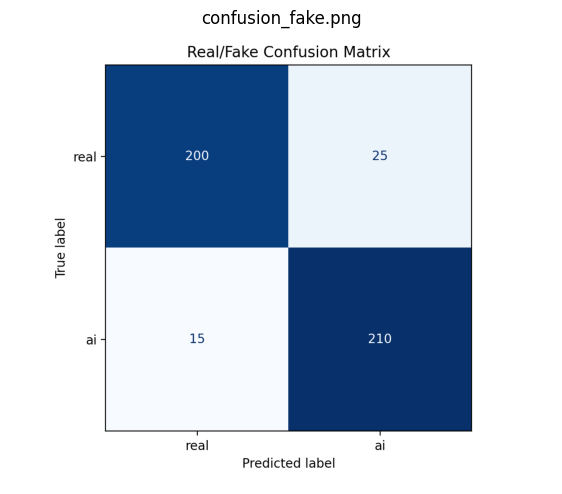

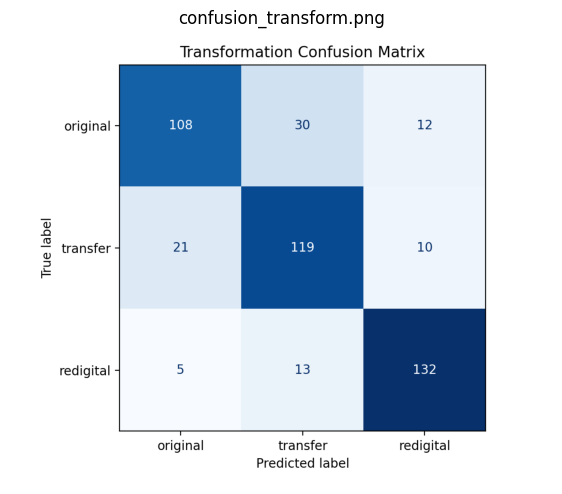

In [78]:
# Show saved confusion matrices if they exist.
for filename in ['confusion_fake.png', 'confusion_transform.png']:
    path = Path(OUTPUT_DIR) / filename
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(7, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(filename)
        plt.show()
    else:
        print(f'Missing: {path}')


#DEPTH

##Depth map generation

###first small debug

In [84]:
!python generate_depth_maps.py \
  --csv_paths data/splits/train_balanced.csv data/splits/val_balanced.csv \
  --image_root /content/RRDataset_subset \
  --depth_root /content/drive/MyDrive/CV_Project/depth_map \
  --model_type MiDaS_small \
  --max_images 20

python3: can't open file '/content/REPO/generate_depth_maps.py': [Errno 2] No such file or directory


###full depth map generation

In [80]:
!python generate_depth_maps.py \
  --csv_paths data/splits/train_balanced.csv data/splits/val_balanced.csv \
  --image_root /content/RRDataset_subset \
  --depth_root /content/drive/MyDrive/CV_Project/depth_map \
  --model_type MiDaS_small

python3: can't open file '/content/REPO/generate_depth_maps.py': [Errno 2] No such file or directory


##First try with depth only

In [81]:
!python train_depth.py \
  --train_csv data/splits/train_balanced.csv \
  --val_csv data/splits/val_balanced.csv \
  --image_root /content/RRDataset_subset \
  --depth_root /content/drive/MyDrive/CV_Project/depth_map \
  --epochs 5 \
  --batch_size 16 \
  --lr 1e-4 \
  --image_size 224 \
  --checkpoint_dir checkpoints \
  --checkpoint_name best_depth_only.pt \
  --no_edge

python3: can't open file '/content/REPO/train_depth.py': [Errno 2] No such file or directory


##Second try with also edge consistency

In [82]:
!python train_depth.py \
  --train_csv data/splits/train_balanced.csv \
  --val_csv data/splits/val_balanced.csv \
  --image_root /content/RRDataset_subset \
  --depth_root /content/drive/MyDrive/CV_Project/depth_map \
  --epochs 5 \
  --batch_size 16 \
  --lr 1e-4 \
  --image_size 224 \
  --checkpoint_dir checkpoints \
  --checkpoint_name best_depth_edge.pt

python3: can't open file '/content/REPO/train_depth.py': [Errno 2] No such file or directory
